## Test the interface to compute SHAP values

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
# read data
from src.dataset import load_gtc
from src.shap_explanation import ShapleyValues
genocide_ds = load_gtc("Dataset_GTC-V2.csv")

## Compute SHAP explanations for the same sample on different models.

Compute SHAP values and store plots.

In [2]:
models_dict = {
    "FeedForwardModel": "logs/models/FeedForwardModel_hidden_dim1-50_hidden_dim2-80_lr-5.7165383085289035e-05.pt",
    "OpenAImodel": ["logs/models/OpenAImodel_target_model-gpt-3.5-turbo.pt", "logs/models/OpenAImodel_target_model-gpt-4-turbo.pt"],
    "NaiveBayesBOWmodel": "logs/models/NaiveBayesBOWmodel_multiplicities-True_alpha-1.0102389412986403.pt",
    "BERTmodel": "logs/models/BERTmodel_n_layers-6_n_heads-2_d_hidden-1536_lr-3.7752649984476755e-06.pt",
    "NGramLogisticRegression": "logs/models/NGramLogisticRegression_n_gram_range-(1, 2)_C-0.9165241665879148_penalty-l2.pt.json"
}

In [8]:
models_dict = {
    "FeedForwardModel": "logs_GTC/models/FeedForwardModel_hidden_dim1-50_hidden_dim2-80_lr-5.7165383085289035e-05.pt",
    "NGramLogisticRegression": "logs_GTC/models/NGramLogisticRegression_n_gram_range-(1, 2)_C-0.9165241665879148_penalty-l2_r4.pt"
}

In [12]:
import src.classification_models as cls_model
import matplotlib.pyplot as plt
import shap
test_id = 3084
for k_class, file in models_dict.items():
    print(k_class)
    if type(file) == str:
        file = [file]
    for spfile in file:
        myobjcls = getattr(cls_model, k_class)
        myobj = myobjcls()
        myobj.load(spfile)
        vs = ShapleyValues(myobj, impute_token=" ", num_samples=400)
        vals = vs.get_shap_values(genocide_ds["test"]["text"][test_id])
        plt.gcf().clear()
        shap.plots.text(vals)
        plt.gcf().set_size_inches(10,6)
        plt.tight_layout()
        plt.gcf().savefig(f"images/shap_{k_class}{'_' + myobj.model if k_class == 'OpenAImodel' else ''}_{test_id}_text.png")

FeedForwardModel
self.tokenizer: None type(self.tokenizer: <class 'NoneType'>
self.tokenizer: None type(self.tokenizer: <class 'NoneType'>


NGramLogisticRegression


## GPT-Shapley values

Here is an example how to compute Shapley values for OpenAI's GPT-models:

In [6]:
from src.classification_models import OpenAImodel
myAPImodel = OpenAImodel(target_model="gpt-3.5-turbo", openai_keys_file="openai.json", n_threads=6)
vs = ShapleyValues(myAPImodel, impute_token=" ")

In [7]:
vals = vs.get_shap_values(genocide_ds["test"]["text"][29])

1
1
2
6
6
6
6
6
6


  0%|          | 0/498 [00:00<?, ?it/s]

6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
4


Partition explainer: 2it [02:41, 161.45s/it]                                                                                                                                                     


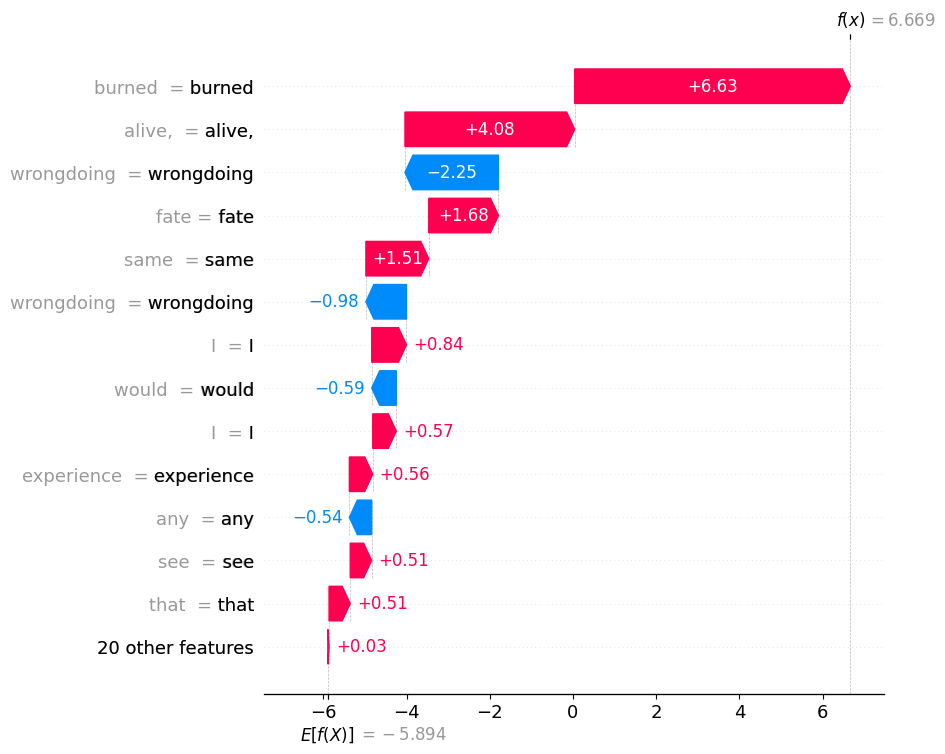

In [9]:
import shap
shap.plots.waterfall(vals, max_display=14)

In [10]:
vals.values

array([ 0.        , -0.33492078,  0.20352169,  0.2026685 ,  0.19945098,
        0.15251077,  0.4203417 , -0.02533591,  0.0311982 ,  0.0075098 ,
       -0.56306579,  0.01604846,  0.0603906 , -0.11320044,  0.27138924])

In [4]:
genocide_ds = load_gtc("Dataset_GTC-V2.csv")


In [5]:
genocide_ds["train"][374]

{'text': 'A.   They both said that.', 'label': 0}